<!-- Qalhata Technologies | Applied Data Science & ML with Python and dbt -->
# Lab 3 - Explore and find one insight (solution)

**Day 1 lab**

> Convention for this course: run cells top to bottom. Before you trust a result, use **Kernel > Restart Kernel and Run All Cells**. If it survives that, it is real.


## Lab 3 | Explore, and find one insight  ·  ~60 minutes

Use the **four EDA questions** from the slides on your cleaned data, then state **one finding in plain English** at the end. That sentence is the deliverable.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_data_dir():
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / 'data' / 'processed' / 'service_requests_clean.csv').exists():
            return cand / 'data'
    raise FileNotFoundError('Run Lab 2 first to create the cleaned dataset')

DATA = find_data_dir()
df = pd.read_csv(DATA / 'processed' / 'service_requests_clean.csv',
                 parse_dates=['submitted_at', 'resolved_at'])
print(df.shape)
df.head()

(12027, 14)


,request_id,submitted_at,service_id,channel_id,district_id,department_id,priority,status,resolved_at,resolution_hours,satisfaction_score,citizen_age_band,target_resolution_hours,sla_met
0,1003304,2024-07-13 06:38:00,13,1,101,2,Low,Open,NaT,99.2,NaN,35-44,72,NaN
1,1011864,2024-05-22 13:06:00,19,2,100,5,High,Resolved,2024-05-24 09:36:00,44.5,NaN,25-34,96,1.0
2,1001507,2024-02-13 01:07:00,10,1,104,1,Low,Resolved,2024-02-13 16:43:00,15.6,NaN,25-34,24,1.0
3,1004483,2024-09-24 08:11:00,13,5,104,2,Medium,Resolved,2024-10-01 07:29:00,167.3,4.0,18-24,72,0.0
4,1004626,2024-07-08 07:16:00,10,5,105,1,High,Resolved,2024-07-09 00:04:00,16.8,1.0,55-64,24,1.0


### Q1 - What is in here?
`describe()` for numbers, `info()` for structure.

In [2]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
request_id,12027.0,NaN,NaN,NaN,1005998.519248,1000000.0,1003001.5,1005995.0,1008997.5,1011999.0,3463.586694
submitted_at,12027,NaN,NaN,NaN,2024-07-29 11:18:02.020453888,2024-01-01 00:25:00,2024-04-13 05:04:00,2024-07-30 06:37:00,2024-11-10 20:59:30,2025-02-28 23:29:00,NaN
service_id,12027.0,NaN,NaN,NaN,13.895153,10.0,11.0,13.0,17.0,19.0,2.990405
channel_id,12027.0,NaN,NaN,NaN,2.38056,1.0,1.0,2.0,3.0,5.0,1.384478
district_id,12027.0,NaN,NaN,NaN,102.490729,100.0,101.0,102.0,104.0,105.0,1.712976
department_id,12027.0,NaN,NaN,NaN,2.412322,1.0,1.0,2.0,4.0,5.0,1.523154
priority,12027,3,Low,5432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,12027,3,Resolved,9891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolved_at,10479,NaN,NaN,NaN,2024-08-01 14:34:50.626968320,2024-01-01 19:13:00,2024-04-16 07:31:00,2024-08-02 19:08:00,2024-11-14 06:50:30,2025-03-16 08:43:00,NaN
resolution_hours,11992.0,NaN,NaN,NaN,67.812558,0.0,24.4,44.1,81.925,1145.5,74.780149


### Q2 - How common is each category?
Check `priority` and `status`. After cleaning, each label should now be single and sensible.

In [3]:
print(df['priority'].value_counts())
print()
print(df['status'].value_counts())

priority
Low       5432
Medium    4831
High      1764
Name: count, dtype: int64

status
Resolved    9891
Open        1528
Reopened     608
Name: count, dtype: int64


### Q3 - Does the target differ by group?
Mean resolution time by channel. Join the channel names to make it readable. This is where the first real insight usually appears.

In [4]:
channels = pd.read_csv(DATA / 'seeds' / 'channels.csv')
by_channel = (df.merge(channels, on='channel_id', how='left')
                .groupby('channel_name')['resolution_hours'].mean()
                .sort_values())
by_channel

channel_name
Web Portal        60.830905
Mobile App        61.310353
WhatsApp          63.573443
Walk-in Centre    86.306401
Call Centre       89.785817
Name: resolution_hours, dtype: float64

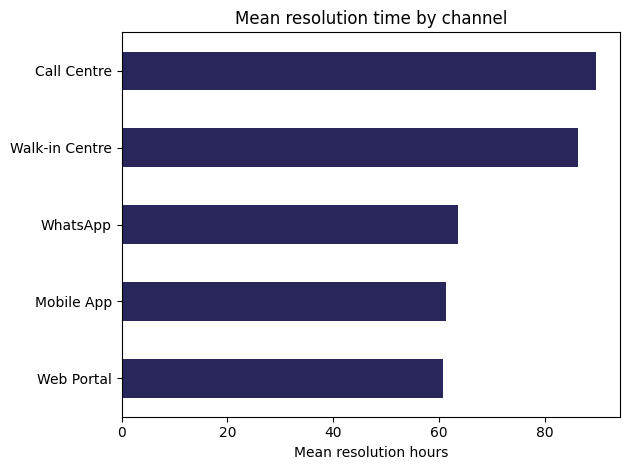

In [5]:
by_channel.plot(kind='barh', color='#28265B')
plt.xlabel('Mean resolution hours'); plt.ylabel('')
plt.title('Mean resolution time by channel'); plt.tight_layout(); plt.show()

### Q4 - What moves with what?
A quick correlation on the numeric columns. Early hints at features for the Day 3 model.

In [6]:
df[['resolution_hours', 'target_resolution_hours', 'satisfaction_score']].corr()

,resolution_hours,target_resolution_hours,satisfaction_score
resolution_hours,1.000000,0.751716,0.001146
target_resolution_hours,0.751716,1.000000,-0.004212
satisfaction_score,0.001146,-0.004212,1.000000


### Your one finding
In one or two sentences of plain English, state something true and useful you found. Example shape: *"Digital channels (portal, app) resolve requests faster on average than the call centre, by roughly X hours."*

_Write your finding here:_

> ...

**Wrap-up:** you took a messy extract to a cleaned, explored dataset and a stated insight - a complete, if small, analytics workflow in a day. Tomorrow we make this visual and persuasive with Matplotlib and Seaborn.